## Step 1: Dataset Upload

In this step, the sustainability dataset is uploaded into the Google Colab environment for further analysis and preprocessing.

The dataset contains sustainability indicators for multiple countries, including recycling rates, waste generation, renewable energy usage and carbon footprint values.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Global_Sustainability_Dataset - Sheet1.csv to Global_Sustainability_Dataset - Sheet1.csv


## Step 2: Importing the Dataset

In this step, the uploaded sustainability dataset is imported into Python using the Pandas library.

The dataset contains information about recycling rates, waste generation, renewable energy usage and carbon footprint for different countries.

In [2]:
import pandas as pd

df = pd.read_csv("Global_Sustainability_Dataset - Sheet1.csv")

In [3]:
df.head()

,Country,Recycling_Rate,Waste_Generated,Renewable_Energy,Carbon_Footprint,Sustainability_Level
0,India,32,500,42,2.1,Medium
1,Germany,68,220,55,0.9,High
2,Norway,82,120,85,0.7,High
3,USA,35,650,35,2.5,Medium
4,China,28,800,30,3.2,Low


## Step 3: Understanding the Dataset

Before applying K Means Clustering, it is important to understand the structure of the dataset and check for missing values or inconsistencies.

This helps in identifying the data types of each column and ensures that the dataset is ready for preprocessing and clustering.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               12 non-null     object 
 1   Recycling_Rate        12 non-null     int64  
 2   Waste_Generated       12 non-null     int64  
 3   Renewable_Energy      12 non-null     int64  
 4   Carbon_Footprint      12 non-null     float64
 5   Sustainability_Level  12 non-null     object 
dtypes: float64(1), int64(3), object(2)
memory usage: 708.0+ bytes


## Step 4: Data Cleaning

The dataset was checked for missing values before performing clustering.

No missing values were found in the dataset, so no additional data cleaning was required.

This ensures that the clustering algorithm receives complete and reliable information.

In [5]:
df.isnull().sum()

,0
Country,0
Recycling_Rate,0
Waste_Generated,0
Renewable_Energy,0
Carbon_Footprint,0
Sustainability_Level,0


## Step 5: Selecting Features for Clustering

K Means Clustering works only with numerical data.

For this reason, only numerical sustainability indicators were selected for clustering, while categorical columns such as Country and Sustainability Level were excluded from the clustering process.

In [6]:
X = df[
    [
        "Recycling_Rate",
        "Waste_Generated",
        "Renewable_Energy",
        "Carbon_Footprint"
    ]
]

X.head()

,Recycling_Rate,Waste_Generated,Renewable_Energy,Carbon_Footprint
0,32,500,42,2.1
1,68,220,55,0.9
2,82,120,85,0.7
3,35,650,35,2.5
4,28,800,30,3.2


## Step 6: Feature Scaling

Since K Means Clustering uses distance calculations to form clusters, it is important that all features are on a similar scale.

StandardScaler was used to standardize the numerical features so that each feature contributes equally to the clustering process.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [8]:
X_scaled[:5]

array([[-1.13210083,  0.7606521 , -0.46023425,  0.63181116],
       [ 1.1532616 , -0.68329765,  0.3944865 , -0.9928461 ],
       [ 2.04201366, -1.19899398,  2.36691898, -1.26362231],
       [-0.94165397,  1.5341966 , -0.92046849,  1.17336357],
       [-1.38602999,  2.30774111, -1.24920724,  2.12108031]])

## Step 7: Determining the Optimal Number of Clusters

Before applying K Means Clustering, it is important to determine the optimal number of clusters.

The Elbow Method is used for this purpose. It calculates the Within Cluster Sum of Squares (WCSS) for different values of K and helps identify the point where adding more clusters provides diminishing returns.

In [10]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

## Step 8: Visualizing the Elbow Method

The Elbow Method was visualized to determine the optimal number of clusters for the dataset.

The point where the decrease in WCSS starts slowing down significantly is considered the optimal value of K.

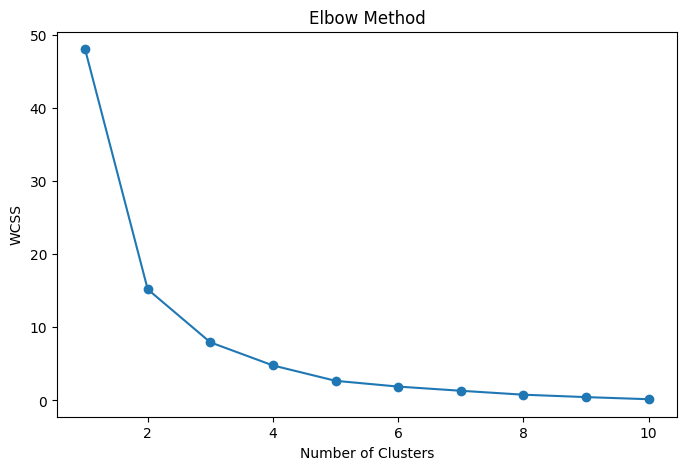

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

## Step 9: Selecting the Number of Clusters

Based on the Elbow Method, the optimal number of clusters was selected as 3.

After K = 3, the reduction in WCSS becomes much smaller, indicating that additional clusters provide limited improvement.

Therefore, K = 3 was chosen for performing K Means Clustering.

In [12]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

## Step 10: Assigning Cluster Labels

After training the K Means model, each country was assigned to a cluster based on its sustainability characteristics.

Countries within the same cluster share similar values for recycling rate, waste generation, renewable energy usage and carbon footprint.

In [13]:
df["Cluster"] = clusters

df[["Country", "Cluster"]]

,Country,Cluster
0,India,1
1,Germany,0
2,Norway,2
3,USA,1
4,China,1
5,Brazil,0
6,Japan,0
7,Australia,0
8,Canada,0
9,UK,0


## Step 11: Visualizing the Clusters

The clusters formed by the K Means algorithm were visualized to better understand the grouping of countries based on their sustainability indicators.

The graph helps identify countries with similar environmental and sustainability characteristics.

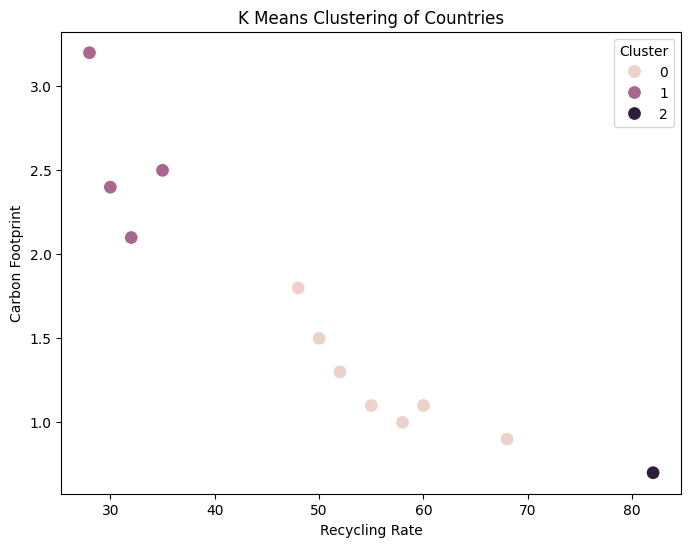

In [15]:
import seaborn as sns
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Recycling_Rate"],
    y=df["Carbon_Footprint"],
    hue=df["Cluster"],
    s=100
)

plt.title("K Means Clustering of Countries")
plt.xlabel("Recycling Rate")
plt.ylabel("Carbon Footprint")

plt.show()

## Step 12: Evaluating the Clustering Model

The quality of the clusters was evaluated using the Silhouette Score.

The Silhouette Score measures how similar a data point is to its own cluster compared to other clusters.

A value closer to 1 indicates well-separated and meaningful clusters, while values close to 0 indicate overlapping clusters.

In [16]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.5135961337117932


# Step 13: Insights and Conclusion

## Cluster Evaluation

The K Means Clustering model achieved a Silhouette Score of 0.514.

A Silhouette Score greater than 0.5 generally indicates that the clusters are reasonably well separated and that the data points are grouped appropriately.

Therefore, the clustering performance can be considered satisfactory for this sustainability dataset.

## Key Insights

- Countries with high recycling rates and high renewable energy usage were grouped into the same cluster.

- Countries with high waste generation and high carbon footprint formed a separate cluster.

- Countries with moderate sustainability indicators formed another intermediate cluster.

- The clustering process successfully identified countries with similar environmental characteristics and sustainability profiles.

## Why K = 3 was Selected

The Elbow Method showed a significant decrease in WCSS values up to K = 3.

After K = 3, the reduction in WCSS became much smaller, indicating diminishing returns from creating additional clusters.

Therefore, three clusters were selected as the optimal choice for this dataset.

## Conclusion

In this project, K Means Clustering was applied to a sustainability dataset containing environmental indicators from multiple countries.

The project involved:

- Dataset import and preprocessing
- Missing value analysis
- Feature selection
- Feature scaling using StandardScaler
- Determination of optimal clusters using the Elbow Method
- Application of K Means Clustering
- Cluster visualization
- Cluster evaluation using Silhouette Score

The model successfully grouped countries with similar sustainability characteristics and provided useful insights into global environmental performance patterns.